In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================

# Run this cell first if packages are not installed
# !pip install pandas numpy matplotlib seaborn tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations, permutations
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")

c:\Users\user\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ All libraries imported successfully.


In [2]:
# ============================================================
# CELL 2: Load the Dataset
# ============================================================

FILE_PATH = "Food_Inspections_20240215.csv"  # Update path if needed

df = pd.read_csv(FILE_PATH, dtype=str, low_memory=False)

# Standardize column names (strip whitespace)
df.columns = df.columns.str.strip()

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

✅ Dataset loaded: 267,531 rows × 17 columns

📋 Columns (17):
   1. Inspection ID
   2. DBA Name
   3. AKA Name
   4. License #
   5. Facility Type
   6. Risk
   7. Address
   8. City
   9. State
  10. Zip
  11. Inspection Date
  12. Inspection Type
  13. Results
  14. Violations
  15. Latitude
  16. Longitude
  17. Location


In [3]:
import re
import time
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from thefuzz import fuzz

# ══════════════════════════════════════════════════════════════
#  CONSTANTS
# ══════════════════════════════════════════════════════════════

# ── Geographic ────────────────────────────────────────────────
CHICAGO_LAT_MIN =  41.60
CHICAGO_LAT_MAX =  42.05
CHICAGO_LON_MIN = -88.00
CHICAGO_LON_MAX = -87.20

TARGET_STATE          = "IL"
TARGET_CITY           = "CHICAGO"
TARGET_ZIP_PREFIXES   = ("606", "607", "608")
TARGET_ZIP_LENGTH     = 5
CITY_FUZZ_THRESHOLD   = 80
DROP_NON_TARGET_CITIES = True

CITY_MANUAL_MAP = {
    "INACTIVE": "CHICAGO",
    "NAN":      "CHICAGO",
}

# ── Risk ──────────────────────────────────────────────────────
TARGET_RISKS = ["RISK 1 (HIGH)", "RISK 2 (MEDIUM)", "RISK 3 (LOW)"]

# ── Facility Type ─────────────────────────────────────────────
TYPE_DESCRIPTIONS = {
    "Bakery": "Bakery bread pastry cakes baked goods patisserie",
    "Banquet Hall": "Banquet hall event venue catering reception wedding party room",
    "Candy Store": "Candy store sweets confectionery sugar snacks chocolate gelato",
    "Caterer": "Caterer catering food service commissary kitchen prep cooking",
    "Coffee Shop": "Coffee shop cafe espresso drinks tea kiosk smoothie beverages",
    "Day Care Center (for ages less than 2)": "Day care infant toddler baby nursery under 2 years children",
    "Day Care Center (for ages 2 - 6)": "Day care preschool children ages 2 to 6 years kindergarten",
    "Day Care Center (combo, for ages less than 2 and 2 - 6 combined)": "Day care combo infant toddler preschool all ages children facility",
    "Gas Station": "Gas station fuel petrol convenience store mini mart service station",
    "Golden Diner": "Golden diner classic American diner breakfast lunch",
    "Grocery Store": "Grocery store supermarket food retail produce market butcher",
    "Hospital": "Hospital medical healthcare clinic nursing patient care",
    "Long Term Care Center (Nursing Home)": "Nursing home long term care assisted living senior elderly residential care",
    "Liquor Store": "Liquor store alcohol beer wine spirits packaged goods",
    "Mobile Food Dispenser": "Mobile food truck cart vendor pushcart dispenser frozen dessert street food",
    "Restaurant": "Restaurant dining food service eating establishment bar grill tavern pub",
    "Paleteria": "Paleteria ice cream paleta Mexican frozen treats sorbet",
    "School": "School education classroom students learning academy cafeteria charter",
    "Shelter": "Shelter homeless housing refuge non-profit aid charity social services",
    "Tavern": "Tavern bar pub lounge brewery brewpub alcohol drinks nightclub hookah",
    "Social Club": "Social club VFW hall community organization members recreation",
    "Wholesaler": "Wholesaler wholesale distributor bulk food warehouse distribution",
    "Wrigley Field Rooftop": "Wrigley field rooftop Chicago Cubs baseball stadium venue",
}

ABBREV_MAP = {
    r"\bREST\b": "RESTAURANT",        r"\bGROC\b": "GROCERY",
    r"\bLIQ\b": "LIQUOR",             r"\bMFD\b": "MOBILE FOOD DISPENSER",
    r"\bBAK\b": "BAKERY",             r"\bCAT\b": "CATERER",
    r"\bBKRY\b": "BAKERY",            r"\bDELI\b": "DELICATESSEN",
    r"\bMOBIL\b": "MOBILE",           r"\bRSTAURANT\b": "RESTAURANT",
    r"\bRESATURANT\b": "RESTAURANT",  r"\bTENT\b": "TEMPORARY",
    r"\bCOMMISARY\b": "COMMISSARY",   r"\bCOMMIASARY\b": "COMMISSARY",
    r"\bPREPACKAGE\b": "PREPACKAGED", r"\bDAYCARE\b": "DAY CARE",
    r"\bNP\b": "NON PROFIT",          r"\bVFW\b": "VETERANS SOCIAL CLUB",
    r"\bGYM\b": "FITNESS CENTER",     r"\bSPA\b": "WELLNESS CENTER",
    r"\bPUB\b": "TAVERN BAR",
}

MANUAL_OVERRIDES = {
    # "exact original Facility Type string": "Official Type",
}

CHICAGO_ADDRESS_PATTERN = re.compile(r"""
    ^
    \d+(?:-\d+)?(?:\s+\d+/\d+)?
    (?:\s+[NSEW](?:ORTH|OUTH|AST|EST)?)?
    (?:\s+[A-Z0-9\'.]+)+
    \s+(?:ST|AVE|BLVD|DR|RD|CT|LN|PL|PKWY|HWY|CIR|TER|TRL|WAY|
            MARKET|RUN|ROW|PATH|WALK|LOOP|XING|PASS|SQ|EXPY|FRWY)
    (?:\s+(?:APT|STE|UNIT|FL|FLOOR|BLDG|RM|\#|LBBY)[\s\w\#-]*)?
    $
""", re.VERBOSE)


# ══════════════════════════════════════════════════════════════
#  STEP 1 — Risk
#  Drops rows whose Risk value is not in TARGET_RISKS
# ══════════════════════════════════════════════════════════════

def clean_risk(df: pd.DataFrame, col="Risk") -> pd.DataFrame:
    result = df.copy()
    result[col] = result[col].astype(str).str.upper().str.strip()

    invalid_mask = ~result[col].isin(TARGET_RISKS)
    print(f"  Valid Risk rows   : {(~invalid_mask).sum():,}")
    print(f"  Dropped (invalid) : {invalid_mask.sum():,}")
    if invalid_mask.any():
        print(f"  Invalid values seen:")
        print(result.loc[invalid_mask, col].value_counts(dropna=False).to_string())

    return result[~invalid_mask].copy()


# ══════════════════════════════════════════════════════════════
#  STEP 2 — Address
#  Cleans and flags addresses — never drops rows
# ══════════════════════════════════════════════════════════════

def clean_address(address: str) -> str:
    if not isinstance(address, str):
        return ""
    return " ".join(address.upper().split())

def is_valid_chicago_address(address: str) -> bool:
    return bool(CHICAGO_ADDRESS_PATTERN.match(address))

def clean_address_column(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["Address"] = result["Address"].apply(clean_address)
    result["address_is_valid"] = result["Address"].apply(is_valid_chicago_address)

    n_invalid = (~result["address_is_valid"]).sum()
    print(f"  Valid addresses   : {result['address_is_valid'].sum():,}")
    print(f"  Invalid addresses : {n_invalid:,} (flagged, not dropped)")
    return result


# ══════════════════════════════════════════════════════════════
#  STEP 3 — Coordinates → State → City → Zip
#  3a: Fix State/City from Location coords (no drops)
#  3b: Clean State  → drop non-IL
#  3c: Clean City   → fuzz match → drop non-Chicago
#  3d: Clean Zip    → drop invalid zip codes
# ══════════════════════════════════════════════════════════════

def parse_coord(value):
    if pd.isna(value):
        return None
    match = re.search(r"-?\d+\.\d+", str(value).strip())
    return float(match.group()) if match else None

def parse_location_pair(value):
    if pd.isna(value):
        return None, None
    nums = re.findall(r"-?\d+\.\d+", str(value).strip())
    return (float(nums[0]), float(nums[1])) if len(nums) >= 2 else (None, None)

def is_inside_chicago(lat, lon):
    if lat is None or lon is None:
        return False
    return (CHICAGO_LAT_MIN <= lat <= CHICAGO_LAT_MAX and
            CHICAGO_LON_MIN <= lon <= CHICAGO_LON_MAX)

def build_location(lat, lon):
    return f"({lat}, {lon})" if lat is not None and lon is not None else None

def clean_location_state_city_zip(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    # ── 3a: Fix State/City from coordinates ───────────────────
    print("\n  [3a] Fixing State/City from Location coordinates...")
    result["_loc_lat"] = result["Location"].apply(lambda x: parse_location_pair(x)[0])
    result["_loc_lon"] = result["Location"].apply(lambda x: parse_location_pair(x)[1])

    location_present = result["_loc_lat"].notna() & result["_loc_lon"].notna()
    inside_chicago   = result.apply(
        lambda r: is_inside_chicago(r["_loc_lat"], r["_loc_lon"]), axis=1)
    fix_mask = location_present & inside_chicago

    state_needs_fix = fix_mask & (
        result["State"].isna() |
        (result["State"].astype(str).str.strip().str.upper() != "IL"))
    city_needs_fix = fix_mask & (
        result["City"].isna() |
        (result["City"].astype(str).str.strip().str.upper() != "CHICAGO"))

    result.loc[fix_mask, "State"] = "IL"
    result.loc[fix_mask, "City"]  = "CHICAGO"
    print(f"  State corrected to IL      : {state_needs_fix.sum():,}")
    print(f"  City corrected to CHICAGO  : {city_needs_fix.sum():,}")

    # Fill null Locations with IL average
    result["_lat_f"] = result["Latitude"].apply(parse_coord)
    result["_lon_f"] = result["Longitude"].apply(parse_coord)
    valid_coords = result["_lat_f"].notna() & result["_lon_f"].notna()
    il_avg_lat   = round(result.loc[valid_coords, "_lat_f"].mean(), 6)
    il_avg_lon   = round(result.loc[valid_coords, "_lon_f"].mean(), 6)
    loc_null_mask = (
        result["Location"].isna() |
        result["Location"].astype(str).str.strip().isin(["", "nan"]))
    result.loc[loc_null_mask, "Location"]  = build_location(il_avg_lat, il_avg_lon)
    result.loc[loc_null_mask, "Latitude"]  = il_avg_lat
    result.loc[loc_null_mask, "Longitude"] = il_avg_lon
    print(f"  Null Locations filled      : {loc_null_mask.sum():,}  "
          f"(avg: {il_avg_lat}, {il_avg_lon})")

    result.drop(columns=["_loc_lat", "_loc_lon", "_lat_f", "_lon_f"],
                inplace=True, errors="ignore")

    # ── 3b: State — drop non-IL ───────────────────────────────
    print("\n  [3b] Dropping non-IL rows...")
    result["State"] = result["State"].astype(str).str.upper().str.strip()
    non_il = result["State"] != TARGET_STATE
    print(f"  Dropped (non-IL) : {non_il.sum():,}")
    result = result[~non_il].copy()

    # ── 3c: City — manual map + fuzz + optional drop ──────────
    print("\n  [3c] Cleaning City...")
    result["City"] = result["City"].astype(str).str.upper().str.strip()
    result["City"] = result["City"].replace(CITY_MANUAL_MAP)

    def apply_fuzz(city_val):
        if city_val == TARGET_CITY:
            return city_val
        return TARGET_CITY if fuzz.ratio(city_val, TARGET_CITY) >= CITY_FUZZ_THRESHOLD else city_val

    result["City"] = result["City"].apply(apply_fuzz)

    non_chicago = result["City"] != TARGET_CITY
    print(f"  Non-Chicago rows : {non_chicago.sum():,}  "
          f"({'dropping' if DROP_NON_TARGET_CITIES else 'keeping'})")
    if DROP_NON_TARGET_CITIES:
        result = result[~non_chicago].copy()

    # ── 3d: Zip ───────────────────────────────────────────────
    print("\n  [3d] Cleaning Zip...")
    result["Zip"] = (result["Zip"].astype(str)
                     .str.replace(r"\.0$", "", regex=True)
                     .str.upper().str.strip())
    invalid_zip = ~(
        result["Zip"].str.startswith(TARGET_ZIP_PREFIXES, na=False) &
        (result["Zip"].str.len() == TARGET_ZIP_LENGTH))
    print(f"  Dropped (invalid Zip) : {invalid_zip.sum():,}")
    result = result[~invalid_zip].copy()

    return result.reset_index(drop=True)


# ══════════════════════════════════════════════════════════════
#  STEP 4 — Facility Type NLP
#  Never drops rows
# ══════════════════════════════════════════════════════════════

def preprocess_facility_type(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).upper().strip()
    for pattern, replacement in ABBREV_MAP.items():
        text = re.sub(pattern, replacement, text)
    text = re.sub(r"[/\-]", " ", text)
    text = re.sub(r"[^A-Z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def clean_facility_type_column(df: pd.DataFrame, model: SentenceTransformer) -> pd.DataFrame:
    result = df.copy()

    official_labels     = list(TYPE_DESCRIPTIONS.keys())
    official_embeddings = model.encode(
        list(TYPE_DESCRIPTIONS.values()), show_progress_bar=False)

    unique_vals   = result["Facility Type"].dropna().unique().tolist()
    preprocessed  = [preprocess_facility_type(v) for v in unique_vals]
    raw_embeddings = model.encode(preprocessed, show_progress_bar=True, batch_size=64)
    sim_matrix    = cosine_similarity(raw_embeddings, official_embeddings)

    lookup = {}
    for i, raw_val in enumerate(unique_vals):
        score      = float(sim_matrix[i].max())
        matched    = official_labels[sim_matrix[i].argmax()]
        confidence = "high" if score >= 0.75 else "medium" if score >= 0.50 else "low"
        lookup[raw_val] = {
            "matched":    MANUAL_OVERRIDES.get(raw_val, matched),
            "score":      round(score, 4),
            "confidence": confidence,
        }

    result["Facility Type Original"]   = result["Facility Type"]
    result["Facility Type"]            = result["Facility Type Original"].map(
        lambda x: lookup.get(x, {}).get("matched", x))
    result["Facility Type Score"]      = result["Facility Type Original"].map(
        lambda x: lookup.get(x, {}).get("score", 0.0))
    result["Facility Type Confidence"] = result["Facility Type Original"].map(
        lambda x: lookup.get(x, {}).get("confidence", "unknown"))

    mapping_df = pd.DataFrame([
        {"Original": r, "Matched to": i["matched"],
         "Score": i["score"], "Confidence": i["confidence"]}
        for r, i in sorted(lookup.items(), key=lambda x: x[1]["score"], reverse=True)
    ])
    low_conf = mapping_df[mapping_df["Confidence"] == "low"]
    if not low_conf.empty:
        print(f"\n  ⚠️  {len(low_conf)} low-confidence matches — review:")
        print(low_conf.to_string(index=False))
    print(f"\n  Confidence breakdown:")
    print(mapping_df["Confidence"].value_counts().to_string())

    return result


# ══════════════════════════════════════════════════════════════
#  MASTER PIPELINE
# ══════════════════════════════════════════════════════════════

def clean_dataframe(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleaning order and what each step drops:

    Step 1 — Risk        : drops rows with invalid Risk values
    Step 2 — Address     : flags invalid addresses (no drops)
    Step 3 — Coords/Geo  : coord correction (no drops)
                           drops non-IL State
                           drops non-Chicago City (if DROP_NON_TARGET_CITIES)
                           drops invalid Zip codes
    Step 4 — Facility Type: NLP remapping (no drops)
    """
    start      = time.time()
    rows_start = len(raw_df)

    print("── Step 1: Risk ─────────────────────────────────────────")
    result = clean_risk(raw_df)

    print("\n── Step 2: Address ──────────────────────────────────────")
    result = clean_address_column(result)

    print("\n── Step 3: Location / State / City / Zip ────────────────")
    result = clean_location_state_city_zip(result)

    print("\n── Step 4: Facility Type NLP ────────────────────────────")
    print("  Loading model...")
    model  = SentenceTransformer("all-MiniLM-L6-v2")
    result = clean_facility_type_column(result, model)

    print(f"\n{'═'*65}")
    print(f"  PIPELINE COMPLETE  ({time.time() - start:.1f}s)")
    print(f"{'═'*65}")
    print(f"  Rows in            : {rows_start:,}")
    print(f"  Rows out           : {len(result):,}")
    print(f"  Total dropped      : {rows_start - len(result):,}")
    print(f"\n  Drop breakdown:")
    print(f"    Step 1 Risk      : invalid Risk value")
    print(f"    Step 3 State     : State != IL (after coord correction)")
    print(f"    Step 3 City      : City != CHICAGO (after fuzz match)")
    print(f"    Step 3 Zip       : invalid Chicago zip prefix/length")
    print(f"\n  No drops in:")
    print(f"    Step 2 Address   : {(~result['address_is_valid']).sum():,} flagged in address_is_valid")

    print(f"    Step 4 Facility  : NLP remapping only")
    return result.reset_index(drop=True)


# ── Run ───────────────────────────────────────────────────────
df = clean_dataframe(df)

── Step 1: Risk ─────────────────────────────────────────
  Valid Risk rows   : 267,398
  Dropped (invalid) : 133
  Invalid values seen:
Risk
NAN    81
ALL    52

── Step 2: Address ──────────────────────────────────────
  Valid addresses   : 249,266
  Invalid addresses : 18,132 (flagged, not dropped)

── Step 3: Location / State / City / Zip ────────────────

  [3a] Fixing State/City from Location coordinates...
  State corrected to IL      : 59
  City corrected to CHICAGO  : 270
  Null Locations filled      : 920  (avg: 41.880734, -87.676429)

  [3b] Dropping non-IL rows...
  Dropped (non-IL) : 11

  [3c] Cleaning City...
  Non-Chicago rows : 195  (dropping)

  [3d] Cleaning Zip...
  Dropped (invalid Zip) : 54

── Step 4: Facility Type NLP ────────────────────────────
  Loading model...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


  ⚠️  229 low-confidence matches — review:
                              Original                                                       Matched to  Score Confidence
                        Shared Kitchen                                                          Caterer 0.4994        low
                      employee kitchen                                                          Caterer 0.4968        low
                       CHURCH/DAY CARE Day Care Center (combo, for ages less than 2 and 2 - 6 combined) 0.4965        low
                             CAFETERIA                                                           School 0.4963        low
                             cafeteria                                                           School 0.4963        low
                             Cafeteria                                                           School 0.4963        low
                          smoothie bar                                                      Coffee Sho

  STEP 1 — Column Classification

  Columns included in IND analysis : 14
  Columns excluded (noise/ids)     : 7

  Excluded: ['Inspection ID', 'License #', 'Zip', 'Violations', 'Latitude', 'Longitude', 'Facility Type Score']

  Column classification table:


,Column,Type,Unique,Uniqueness,IND useful
0,Inspection ID,id / free_text,267138,100.00%,False
1,DBA Name,free_text,31990,11.98%,True
2,AKA Name,free_text,30463,11.51%,True
3,License #,numeric_code,44315,16.59%,False
4,Facility Type,semi-categorical,23,0.01%,True
5,Risk,categorical,3,0.00%,True
6,Address,free_text,19321,7.23%,True
7,City,categorical,1,0.00%,True
8,State,categorical,1,0.00%,True
9,Zip,numeric_code,62,0.02%,False



  STEP 2 — IND Computation (meaningful columns only)


Computing INDs:   0%|          | 0/182 [00:00<?, ?pair/s]


  Total pairs evaluated : 182
  Exact   (= 1.00)      : 0
  Strong  (≥ 0.90)      : 0
  Partial (0.50–0.90)   : 3
  Weak    (< 0.50)      : 179

  STEP 3 — Key Findings (coverage ≥ 0.04)
  [Partial]  AKA Name                       ⊆  DBA Name
             coverage=0.8016  matched=24,418  |████████████████████████      |
             Unique only in A  : 6,045
             Shared (A ∩ B)    : 24,418
             Unique only in B  : 7,572
             Sample shared     : ['#1 CHOP SUEY', '#1 CHOP SUEY RESTAURANT', '#1 DELI', '#1 DELI, INC', '#1 MARKET INC.']
             Null rate A/B     : 0.9% / 0.0%
             Null-aware cov    : 0.8011

  [Partial]  DBA Name                       ⊆  AKA Name
             coverage=0.7633  matched=24,418  |██████████████████████        |
             Unique only in A  : 7,572
             Shared (A ∩ B)    : 24,418
             Unique only in B  : 6,045
             Sample shared     : ['#1 CHOP SUEY', '#1 CHOP SUEY RESTAURANT', '#1 DELI', '#1 DELI, 

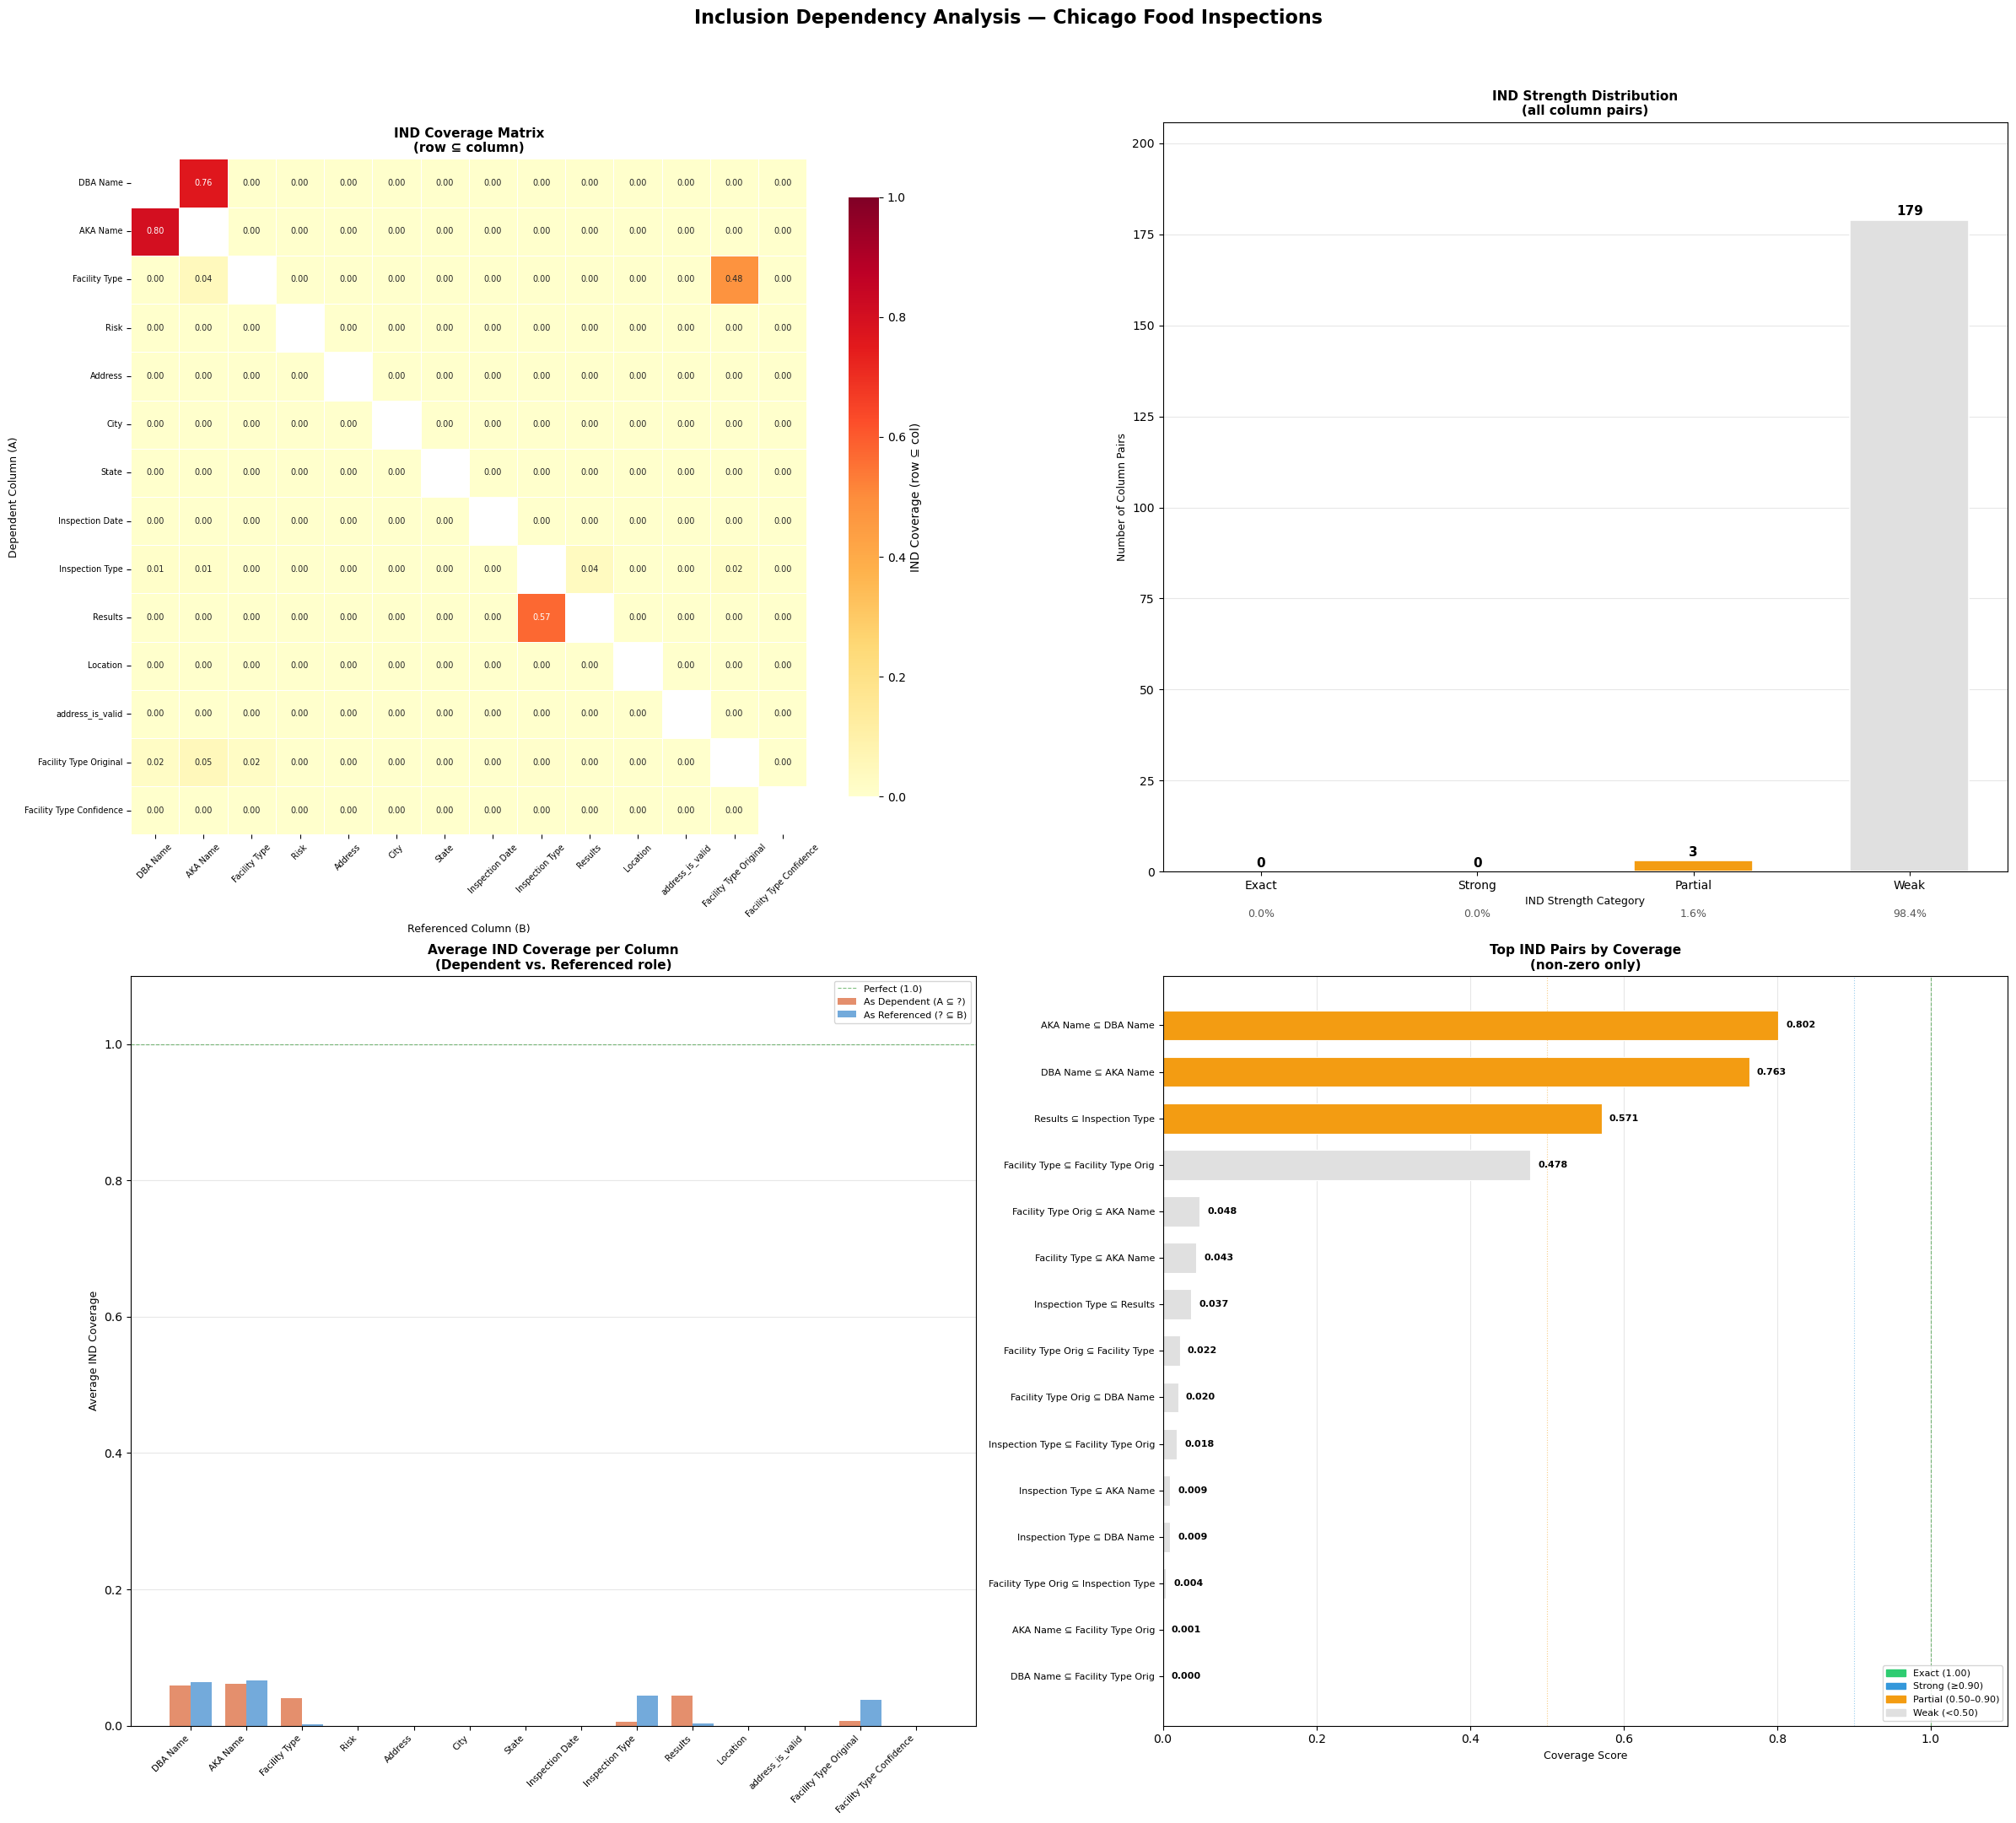

💾 Saved: ind_full_analysis.png

  FINAL SUMMARY

  Dataset           : 267,138 rows × 21 columns
  Columns analysed  : 14 (after excluding ids/coords/numeric codes)
  Columns excluded  : 7
  Pairs evaluated   : 182

  IND Breakdown:
    Exact   (A fully contained in B) : 0
    Strong  (≥90% overlap)           : 0
    Partial (50–90% overlap)          : 3
    Weak    (<50% overlap)            : 179

  Symmetric INDs found              : 0

  Interpretation:
  → The dataset is well-normalised. Columns are largely
    independent, confirming no accidental redundancy.
  → 3 partial IND(s) detected — review the key
    findings above for schema inconsistencies or column overlap.


In [4]:
def run_ind_analysis(df, min_coverage=0.0, include_nulls=False):
    """
    Complete IND Analysis Pipeline:
    - Column type classification (filters noise)
    - IND computation on meaningful columns only
    - Value-level explanation of top findings
    - Null-aware coverage refinement
    - 4 visualisations: heatmap, bar chart, network graph, coverage distribution
    - Printed summary report
    """
    import re
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import seaborn as sns
    from collections import Counter
    from tqdm.notebook import tqdm

    # ══════════════════════════════════════════════════════════
    # PART 1: Column Type Classifier
    # ══════════════════════════════════════════════════════════
    def classify_columns(df):
        results = []
        for col in df.columns:
            series = df[col].dropna().astype(str)
            n_unique  = series.nunique()
            n_total   = len(series)
            uniqueness = n_unique / n_total if n_total else 0
            if uniqueness > 0.95:
                col_type = "id / free_text"
            elif series.str.match(r'^\-?\d+\.\d+$').mean() > 0.9:
                col_type = "coordinate"
            elif series.str.match(r'^\d{4,10}$').mean() > 0.8:
                col_type = "numeric_code"
            elif n_unique <= 20:
                col_type = "categorical"
            elif n_unique <= 500:
                col_type = "semi-categorical"
            else:
                col_type = "free_text"
            results.append({
                "Column":     col,
                "Type":       col_type,
                "Unique":     n_unique,
                "Uniqueness": f"{uniqueness:.2%}",
                "IND useful": col_type not in ("id / free_text", "coordinate", "numeric_code")
            })
        return pd.DataFrame(results)

    # ══════════════════════════════════════════════════════════
    # PART 2: Core IND Engine
    # ══════════════════════════════════════════════════════════
    def compute_ind(df, include_nulls=False, min_coverage=0.0):
        results = []
        columns = df.columns.tolist()
        value_sets = {}
        for col in columns:
            value_sets[col] = (
                set(df[col].astype(str)) if include_nulls
                else set(df[col].dropna().astype(str))
            )
        total_pairs = len(columns) * (len(columns) - 1)
        with tqdm(total=total_pairs, desc="Computing INDs", unit="pair") as pbar:
            for dep in columns:
                dep_vals   = value_sets[dep]
                dep_unique = len(dep_vals)
                for ref in columns:
                    if dep == ref:
                        pbar.update(1)
                        continue
                    ref_vals   = value_sets[ref]
                    ref_unique = len(ref_vals)
                    matched    = len(dep_vals & ref_vals)
                    coverage   = matched / dep_unique if dep_unique > 0 else 0.0
                    if coverage >= min_coverage:
                        results.append({
                            "dependent":  dep,
                            "referenced": ref,
                            "dep_unique": dep_unique,
                            "ref_unique": ref_unique,
                            "matched":    matched,
                            "coverage":   round(coverage, 6),
                            "is_exact":   coverage == 1.0,
                            "is_trivial": (dep_unique == ref_unique == matched),
                            "strength":   (
                                "Exact"   if coverage == 1.0  else
                                "Strong"  if coverage >= 0.9  else
                                "Partial" if coverage >= 0.5  else
                                "Weak"
                            )
                        })
                    pbar.update(1)
        result_df = pd.DataFrame(results)
        result_df.sort_values(["coverage", "dep_unique"],
                              ascending=[False, True], inplace=True)
        return result_df.reset_index(drop=True)

    # ══════════════════════════════════════════════════════════
    # PART 3: Value-level explanation
    # ══════════════════════════════════════════════════════════
    def explain_overlap(df, col_a, col_b, n=10):
        vals_a  = set(df[col_a].dropna().astype(str))
        vals_b  = set(df[col_b].dropna().astype(str))
        shared  = vals_a & vals_b
        only_a  = vals_a - vals_b
        only_b  = vals_b - vals_a
        return {
            "pair":         f"{col_a} ⊆ {col_b}",
            "shared":       len(shared),
            "only_in_A":    len(only_a),
            "only_in_B":    len(only_b),
            "sample_shared": sorted(shared)[:n],
            "sample_only_a": sorted(only_a)[:5],
        }

    # ══════════════════════════════════════════════════════════
    # PART 4: Null-aware refinement
    # ══════════════════════════════════════════════════════════
    def null_aware_coverage(df, col_a, col_b):
        both   = df[[col_a, col_b]].dropna()
        vals_a = set(both[col_a].astype(str))
        vals_b = set(both[col_b].astype(str))
        cov    = len(vals_a & vals_b) / len(vals_a) if vals_a else 0
        return {
            "null_rate_A":    round(df[col_a].isna().mean() * 100, 2),
            "null_rate_B":    round(df[col_b].isna().mean() * 100, 2),
            "rows_used":      len(both),
            "null_aware_cov": round(cov, 4),
        }

    # ══════════════════════════════════════════════════════════
    # STEP A: Classify columns
    # ══════════════════════════════════════════════════════════
    print("=" * 65)
    print("  STEP 1 — Column Classification")
    print("=" * 65)
    type_df     = classify_columns(df)
    useful_cols = type_df[type_df["IND useful"]]["Column"].tolist()
    excluded    = type_df[~type_df["IND useful"]]["Column"].tolist()

    print(f"\n  Columns included in IND analysis : {len(useful_cols)}")
    print(f"  Columns excluded (noise/ids)     : {len(excluded)}")
    print(f"\n  Excluded: {excluded}")
    print(f"\n  Column classification table:")
    display(type_df)

    # ══════════════════════════════════════════════════════════
    # STEP B: Run IND on meaningful columns only
    # ══════════════════════════════════════════════════════════
    print("\n" + "=" * 65)
    print("  STEP 2 — IND Computation (meaningful columns only)")
    print("=" * 65)
    df_filtered = df[useful_cols]
    ind_results = compute_ind(df_filtered,
                              include_nulls=include_nulls,
                              min_coverage=min_coverage)

    n_exact   = ind_results["is_exact"].sum()
    n_strong  = (ind_results["coverage"] >= 0.9).sum()
    n_partial = ((ind_results["coverage"] >= 0.5) & (ind_results["coverage"] < 0.9)).sum()
    n_weak    = (ind_results["coverage"] < 0.5).sum()

    print(f"\n  Total pairs evaluated : {len(ind_results):,}")
    print(f"  Exact   (= 1.00)      : {n_exact}")
    print(f"  Strong  (≥ 0.90)      : {n_strong}")
    print(f"  Partial (0.50–0.90)   : {n_partial}")
    print(f"  Weak    (< 0.50)      : {n_weak}")

    # ══════════════════════════════════════════════════════════
    # STEP C: Printed findings report — top INDs only
    # ══════════════════════════════════════════════════════════
    print("\n" + "=" * 65)
    print("  STEP 3 — Key Findings (coverage ≥ 0.04)")
    print("=" * 65)

    top_inds = ind_results[ind_results["coverage"] >= 0.04].copy()

    if top_inds.empty:
        print("  No meaningful INDs found above threshold.")
    else:
        for _, row in top_inds.iterrows():
            bar    = "█" * int(row["coverage"] * 30)
            label  = f"  [{row['strength']:7s}]  {row['dependent']:30s} ⊆  {row['referenced']}"
            metric = f"coverage={row['coverage']:.4f}  matched={row['matched']:,}  |{bar:<30}|"
            print(label)
            print(f"             {metric}")

            # Value-level explanation for each meaningful IND
            exp = explain_overlap(df, row["dependent"], row["referenced"])
            print(f"             Unique only in A  : {exp['only_in_A']:,}")
            print(f"             Shared (A ∩ B)    : {exp['shared']:,}")
            print(f"             Unique only in B  : {exp['only_in_B']:,}")
            print(f"             Sample shared     : {exp['sample_shared'][:5]}")

            # Null-aware refinement
            nac = null_aware_coverage(df, row["dependent"], row["referenced"])
            print(f"             Null rate A/B     : {nac['null_rate_A']}% / {nac['null_rate_B']}%")
            print(f"             Null-aware cov    : {nac['null_aware_cov']}")
            print()

    # Symmetric INDs
    exact_set = set(zip(
        ind_results[ind_results["is_exact"]]["dependent"],
        ind_results[ind_results["is_exact"]]["referenced"]
    ))
    symmetric = [(a, b) for (a, b) in exact_set if (b, a) in exact_set and a < b]
    print(f"  Symmetric INDs (A ↔ B, identical value sets) : {len(symmetric)}")
    for a, b in symmetric:
        print(f"    {a}  ↔  {b}")

    # ══════════════════════════════════════════════════════════
    # STEP D: 4 Visualisations
    # ══════════════════════════════════════════════════════════
    print("\n" + "=" * 65)
    print("  STEP 4 — Visualisations")
    print("=" * 65)

    cols = useful_cols
    n    = len(cols)

    fig = plt.figure(figsize=(24, 22))
    fig.suptitle("Inclusion Dependency Analysis — Chicago Food Inspections",
                 fontsize=16, fontweight="bold", y=0.98)

    # ── Plot 1: IND Coverage Heatmap ──────────────────────────
    ax1 = fig.add_subplot(2, 2, 1)

    coverage_matrix = ind_results.pivot(
        index="dependent", columns="referenced", values="coverage"
    ).reindex(index=cols, columns=cols)
    np.fill_diagonal(coverage_matrix.values, 1.0)

    mask = np.eye(n, dtype=bool)
    sns.heatmap(
        coverage_matrix.astype(float),
        ax=ax1,
        mask=mask,
        cmap="YlOrRd",
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor="white",
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        square=True,
        cbar_kws={"label": "IND Coverage (row ⊆ col)", "shrink": 0.8}
    )
    ax1.set_title("IND Coverage Matrix\n(row ⊆ column)", fontsize=11, fontweight="bold")
    ax1.set_xlabel("Referenced Column (B)", fontsize=9)
    ax1.set_ylabel("Dependent Column (A)", fontsize=9)
    ax1.tick_params(axis='x', rotation=45, labelsize=7)
    ax1.tick_params(axis='y', rotation=0,  labelsize=7)

    # ── Plot 2: Strength distribution bar chart ───────────────
    ax2 = fig.add_subplot(2, 2, 2)

    strength_order  = ["Exact", "Strong", "Partial", "Weak"]
    strength_colors = {"Exact": "#2ecc71", "Strong": "#3498db",
                       "Partial": "#f39c12", "Weak": "#e0e0e0"}
    strength_counts = (ind_results["strength"]
                       .value_counts()
                       .reindex(strength_order, fill_value=0))

    bars = ax2.bar(strength_counts.index,
                   strength_counts.values,
                   color=[strength_colors[s] for s in strength_counts.index],
                   edgecolor="white", linewidth=1.2, width=0.55)

    for bar, val in zip(bars, strength_counts.values):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom",
                 fontsize=11, fontweight="bold")

    ax2.set_title("IND Strength Distribution\n(all column pairs)",
                  fontsize=11, fontweight="bold")
    ax2.set_ylabel("Number of Column Pairs", fontsize=9)
    ax2.set_xlabel("IND Strength Category", fontsize=9)
    ax2.set_ylim(0, strength_counts.max() * 1.15)
    ax2.yaxis.grid(True, alpha=0.3)
    ax2.set_axisbelow(True)

    total = strength_counts.sum()
    for i, (cat, val) in enumerate(strength_counts.items()):
        ax2.text(i, -strength_counts.max() * 0.07,
                 f"{val/total:.1%}", ha="center", fontsize=9, color="#555")

    # ── Plot 3: Per-column average coverage bar chart ─────────
    ax3 = fig.add_subplot(2, 2, 3)

    avg_dep = (ind_results.groupby("dependent")["coverage"]
               .mean().reindex(cols).fillna(0))
    avg_ref = (ind_results.groupby("referenced")["coverage"]
               .mean().reindex(cols).fillna(0))

    x     = np.arange(len(cols))
    width = 0.38
    ax3.bar(x - width/2, avg_dep.values, width,
            label="As Dependent (A ⊆ ?)", color="#E07B54", alpha=0.85)
    ax3.bar(x + width/2, avg_ref.values, width,
            label="As Referenced (? ⊆ B)", color="#5B9BD5", alpha=0.85)

    ax3.set_xticks(x)
    ax3.set_xticklabels(cols, rotation=45, ha="right", fontsize=7.5)
    ax3.set_ylabel("Average IND Coverage", fontsize=9)
    ax3.set_title("Average IND Coverage per Column\n(Dependent vs. Referenced role)",
                  fontsize=11, fontweight="bold")
    ax3.set_ylim(0, 1.1)
    ax3.axhline(y=1.0, color="green", linestyle="--",
                linewidth=0.8, alpha=0.5, label="Perfect (1.0)")
    ax3.legend(fontsize=8)
    ax3.yaxis.grid(True, alpha=0.3)
    ax3.set_axisbelow(True)

    # ── Plot 4: Top-N IND horizontal bar chart ────────────────
    ax4 = fig.add_subplot(2, 2, 4)

    top_n  = ind_results[ind_results["coverage"] > 0].head(15).copy()
    top_n  = top_n.sort_values("coverage")
    labels = [f"{r['dependent'][:18]} ⊆ {r['referenced'][:18]}"
              for _, r in top_n.iterrows()]
    colors = [strength_colors[s] for s in top_n["strength"]]

    bars_h = ax4.barh(labels, top_n["coverage"],
                      color=colors, edgecolor="white",
                      linewidth=0.8, height=0.65)

    for bar, val in zip(bars_h, top_n["coverage"]):
        ax4.text(min(val + 0.01, 0.95), bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=8, fontweight="bold")

    legend_patches = [
        mpatches.Patch(color="#2ecc71", label="Exact (1.00)"),
        mpatches.Patch(color="#3498db", label="Strong (≥0.90)"),
        mpatches.Patch(color="#f39c12", label="Partial (0.50–0.90)"),
        mpatches.Patch(color="#e0e0e0", label="Weak (<0.50)"),
    ]
    ax4.legend(handles=legend_patches, fontsize=8, loc="lower right")
    ax4.set_title("Top IND Pairs by Coverage\n(non-zero only)",
                  fontsize=11, fontweight="bold")
    ax4.set_xlabel("Coverage Score", fontsize=9)
    ax4.set_xlim(0, 1.1)
    ax4.axvline(x=1.0, color="green", linestyle="--", linewidth=0.8, alpha=0.5)
    ax4.axvline(x=0.9, color="#3498db", linestyle=":", linewidth=0.8, alpha=0.5)
    ax4.axvline(x=0.5, color="#f39c12", linestyle=":", linewidth=0.8, alpha=0.5)
    ax4.xaxis.grid(True, alpha=0.3)
    ax4.set_axisbelow(True)
    ax4.tick_params(axis='y', labelsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("ind_full_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: ind_full_analysis.png")

    # ══════════════════════════════════════════════════════════
    # STEP E: Final summary table
    # ══════════════════════════════════════════════════════════
    print("\n" + "=" * 65)
    print("  FINAL SUMMARY")
    print("=" * 65)
    print(f"\n  Dataset           : {len(df):,} rows × {len(df.columns)} columns")
    print(f"  Columns analysed  : {len(useful_cols)} (after excluding ids/coords/numeric codes)")
    print(f"  Columns excluded  : {len(excluded)}")
    print(f"  Pairs evaluated   : {len(ind_results):,}")
    print(f"\n  IND Breakdown:")
    print(f"    Exact   (A fully contained in B) : {n_exact}")
    print(f"    Strong  (≥90% overlap)           : {n_strong}")
    print(f"    Partial (50–90% overlap)          : {n_partial}")
    print(f"    Weak    (<50% overlap)            : {n_weak}")
    print(f"\n  Symmetric INDs found              : {len(symmetric)}")
    print(f"\n  Interpretation:")
    if n_exact == 0 and n_strong == 0 and n_partial <= 5:
        print("  → The dataset is well-normalised. Columns are largely")
        print("    independent, confirming no accidental redundancy.")
    if n_partial > 0:
        print(f"  → {n_partial} partial IND(s) detected — review the key")
        print("    findings above for schema inconsistencies or column overlap.")
    if symmetric:
        print(f"  → {len(symmetric)} symmetric pair(s) found — these columns")
        print("    share identical value sets and may be redundant.")

    return ind_results, type_df


# ── Run ───────────────────────────────────────────────────────
ind_results, type_df = run_ind_analysis(df, min_coverage=0.0)